## Pre-process the data

In [1]:
import xarray as xr
import numpy as np
import os
import re
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
from scipy.special import expit  # stable sigmoid
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geodatasets

In [2]:
directory = "/Users/ali/Documents/data/sea-ice-training-validation-4jared/SINGLE-POINT-INJS"
injection_types = [
    "INJANN0N_12Tg",
    "INJANN15N_12Tg",
    "INJANN15S_12Tg",
    "INJANN30N_12Tg",
    "INJANN30S_12Tg",
    "INJMAM60N_12Tg",
    "INJSON60S_12Tg",
]

In [3]:
# Filter ICEFRAC files that also match one of the injection_types in the filename,
# and sort first by injection type, then alphabetically by filename
def get_injection_type(filename):
    for inj in injection_types:
        if inj in filename:
            return inj
    return ""

icefrac_files = sorted(
    [f for f in os.listdir(directory) if 'ICEFRAC' in f and any(inj in f for inj in injection_types)],
    key=lambda f: (get_injection_type(f), f)
)

print("Filtered ICEFRAC files (matching injection_types, sorted by injection type) found in directory:")
for i, file in enumerate(icefrac_files):
    print(f"   {i+1:2d}: {file}")

Filtered ICEFRAC files (matching injection_types, sorted by injection type) found in directory:
    1: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.001.cam.h0.ICEFRAC.203501-206912.nc
    2: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.001.cam.h0.ICEFRAC.204412-206412.nc
    3: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.001.cam.h0.ICEFRAC.206412-206912.nc
    4: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.002.cam.h0.ICEFRAC.203501-206912.nc
    5: b.e21.BWSSP245.f09_g17.release-cesm2.1.5.WACCM-MA-1deg.INJANN0N_12Tg.003.cam.h0.ICEFRAC.203501-207012.nc
    6: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15N_12Tg.001.cam.h0.ICEFRAC.203501-206912.nc
    7: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15N_12Tg.001.cam.h0.ICEFRAC.204501-206412.nc
    8: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15N_12Tg.001.cam.h0.ICEFRAC.206412-206912.nc
    9

In [4]:
# Function to extract and adjust date range from filename
def get_date_range_from_filename(filename):
    # Extract the date range portion (e.g., '20370101-20451231')
    date_match = re.search(r'(\d{6})-(\d{6})', filename)
    if date_match:
        start_date = date_match.group(1)  # YYYYMMDD
        end_date = date_match.group(2)    # YYYYMMDD
        
        start_year = int(start_date[:4])
        start_month = int(start_date[4:6])
        end_year = int(end_date[:4])
        end_month = int(end_date[4:6])
        
        # Adjust start year if not starting in January
        if start_month > 1:
            start_year += 1
            
        # Adjust end year if not ending in December
        if end_month < 12:
            end_year -= 1
            
        return str(start_year), str(end_year)
    return None, None

def process_dataset(filepath, time_slice):
    with xr.open_dataset(filepath) as ds:
        x = ds.sel(time=slice(*time_slice))
        month = x.time.dt.month
        x = x.where((x.lat >= 60) & (month == 9), drop=True)
        x = x.assign_coords(year=x.time.dt.year)
        x = x.groupby('year').first()
    return x

output_dir = './data'
os.makedirs(output_dir, exist_ok=True)

for inj in injection_types:
    print(f"Processing injection type: {inj}")
    # Find ICEFRAC files for this injection type
    matching_files = [f for f in icefrac_files if inj in f]
    if not matching_files:
        print(f"No ICEFRAC file found for injection type '{inj}'")
        continue

    member_results = []
    for f in matching_files:
        print(f"    Processing file: {f}")
        # Get start and end year from filename using date matcher
        start_year, end_year = get_date_range_from_filename(f)
        if (start_year is None) or (end_year is None):
            print(f"Could not extract date range from: {f}, skipping")
            continue
        filepath = os.path.join(directory, f)
        # Process dataset for the actual date range in the file
        dsres = process_dataset(filepath, (start_year, end_year))
        # Expand into ensemble dimension using the member number from filename (e.g. .001., .002., etc)
        m_match = re.search(r'\.(\d{3})\.', f)
        if m_match:
            mnum = int(m_match.group(1))
        # else:
        #     mnum = 1  # fallback
        dsres = dsres.expand_dims('ensemble')
        dsres = dsres.assign_coords(ensemble=[mnum])
        member_results.append(dsres)

    if not member_results:
        print(f"No valid datasets processed for injection type '{inj}'")
        continue

    # Concatenate along ensemble dimension
    icefrac_ens = xr.concat(member_results, dim='ensemble')

    # Average for ensemble members
    icefrac_proc = icefrac_ens.mean(dim='ensemble')#, keep_attrs=True)

    # Rename for clarity before saving
    varname = 'ICEFRAC' if 'ICEFRAC' in icefrac_proc.data_vars else list(icefrac_proc.data_vars)[0]
    icefrac_proc = icefrac_proc.rename({'year': 'time', varname: 'icefrac'})

    # out_filename = os.path.join(output_dir, f"icefrac_60-90_{inj}.nc")
    # icefrac_proc.to_netcdf(out_filename)
    # print(f"Exported processed ice fraction for {inj} to {out_filename}")


Processing injection type: INJANN0N_12Tg
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.001.cam.h0.ICEFRAC.203501-206912.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.001.cam.h0.ICEFRAC.204412-206412.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.001.cam.h0.ICEFRAC.206412-206912.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.002.cam.h0.ICEFRAC.203501-206912.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.5.WACCM-MA-1deg.INJANN0N_12Tg.003.cam.h0.ICEFRAC.203501-207012.nc


/var/folders/m5/8bs7ld1939j1j4p3bznvhzrr0000gn/T/ipykernel_26020/2912017804.py:71: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  icefrac_ens = xr.concat(member_results, dim='ensemble')


Processing injection type: INJANN15N_12Tg
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15N_12Tg.001.cam.h0.ICEFRAC.203501-206912.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15N_12Tg.001.cam.h0.ICEFRAC.204501-206412.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15N_12Tg.001.cam.h0.ICEFRAC.206412-206912.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15N_12Tg.002.cam.h0.ICEFRAC.203501-206912.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.5.WACCM-MA-1deg.INJANN15N_12Tg.003.cam.h0.ICEFRAC.203501-207012.nc
Processing injection type: INJANN15S_12Tg
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15S_12Tg.001.cam.h0.ICEFRAC.203501-206912.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15S_12Tg.001.cam.h0.ICEFRAC.204501-206412.nc


/var/folders/m5/8bs7ld1939j1j4p3bznvhzrr0000gn/T/ipykernel_26020/2912017804.py:71: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  icefrac_ens = xr.concat(member_results, dim='ensemble')


    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15S_12Tg.001.cam.h0.ICEFRAC.206412-206912.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15S_12Tg.002.cam.h0.ICEFRAC.203501-206912.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.5.WACCM-MA-1deg.INJANN15S_12Tg.003.cam.h0.ICEFRAC.203501-207012.nc


...

/var/folders/m5/8bs7ld1939j1j4p3bznvhzrr0000gn/T/ipykernel_26020/2912017804.py:71: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  icefrac_ens = xr.concat(member_results, dim='ensemble')


    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN30S_12Tg.001.cam.h0.ICEFRAC.206412-206912.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN30S_12Tg.002.cam.h0.ICEFRAC.203501-206912.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.5.WACCM-MA-1deg.INJANN30S_12Tg.003.cam.h0.ICEFRAC.203501-207012.nc


/var/folders/m5/8bs7ld1939j1j4p3bznvhzrr0000gn/T/ipykernel_26020/2912017804.py:71: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  icefrac_ens = xr.concat(member_results, dim='ensemble')


Processing injection type: INJMAM60N_12Tg
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJMAM60N_12Tg.001.cam.h0.ICEFRAC.203501-206912.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.5.WACCM-MA-1deg.INJMAM60N_12Tg.002.cam.h0.ICEFRAC.203501-207012.nc
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.5.WACCM-MA-1deg.INJMAM60N_12Tg.003.cam.h0.ICEFRAC.203501-207012.nc
Processing injection type: INJSON60S_12Tg
    Processing file: b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJSON60S_12Tg.001.cam.h0.ICEFRAC.203501-206912.nc


/var/folders/m5/8bs7ld1939j1j4p3bznvhzrr0000gn/T/ipykernel_26020/2912017804.py:71: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  icefrac_ens = xr.concat(member_results, dim='ensemble')


### Process arctic temperature

In [5]:
# Find all *.TREFHT* files that contain both an injection type and "001" in the filename
all_trefht_files = []
for inj in injection_types:
    matched = [f for f in os.listdir(directory) if '.TREFHT' in f and inj in f]
    all_trefht_files.extend(matched)
all_trefht_files = sorted(all_trefht_files)
print(f"Found {len(all_trefht_files)} TREFHT files with '001' and matching injection type in '{directory}':")
for f in all_trefht_files:
    print(f"  {f}")

Found 29 TREFHT files with '001' and matching injection type in '/Users/ali/Documents/data/sea-ice-training-validation-4jared/SINGLE-POINT-INJS':
  b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.001.cam.h0.TREFHT.203501-206912.nc
  b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.001.cam.h0.TREFHT.204412-206412.nc
  b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.001.cam.h0.TREFHT.206412-206912.nc
  b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.002.cam.h0.TREFHT.203501-206912.nc
  b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15N_12Tg.001.cam.h0.TREFHT.203501-206912.nc
  b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15N_12Tg.001.cam.h0.TREFHT.204501-206412.nc
  b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15N_12Tg.001.cam.h0.TREFHT.206412-206912.nc
  b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN15N_12Tg.002.cam.h0.TREFHT.203501-206912.nc
  

In [6]:
# Function to extract and adjust date range from filename
def get_date_range_from_filename(filename):
    # Extract the date range portion (e.g., '20370101-20451231')
    date_match = re.search(r'(\d{6})-(\d{6})', filename)
    if date_match:
        start_date = date_match.group(1)  # YYYYMMDD
        end_date = date_match.group(2)    # YYYYMMDD
        
        start_year = int(start_date[:4])
        start_month = int(start_date[4:6])
        end_year = int(end_date[:4])
        end_month = int(end_date[4:6])
        
        # Adjust start year if not starting in January
        if start_month > 1:
            start_year += 1
            
        # Adjust end year if not ending in December
        if end_month < 12:
            end_year -= 1
            
        return str(start_year), str(end_year)
    return None, None

# Function to process temperature data for each file
def process_temp_dataset(directory, filename, previous_years=None):
    filepath = f"{directory}/{filename}"
    with xr.open_dataset(filepath) as ds:
        ds = ds.load()
    
    # Get date range from filename
    date_range = get_date_range_from_filename(filename)
    ds = ds.sel(time=slice(date_range[0], date_range[1]))
    
    # Remove 'time' coordinate and replace it with 'year' as the main coordinate
    ds = ds.assign_coords(year=ds.time.dt.year)
    ds = ds.swap_dims({'time': 'year'}).drop_vars('time')
    ds = ds.sel(lat=slice(60,90))

    # Remove any years that were in the previous file
    if previous_years is not None:
        ds = ds.where(~ds.year.isin(previous_years), drop=True)
    
    # Calculate weighted mean for Arctic region
    annual_temp = ds.groupby('year').mean()
    
    return annual_temp, annual_temp.year.values

# Function to process ensemble files for one ensemble member (one subdirectory or prefix)
def process_ensemble_files(directory, files):
    ensemble_data = []
    previous_years = None
    for f in files:
        temp_data, years = process_temp_dataset(directory, f, previous_years)
        ensemble_data.append(temp_data)
        previous_years = years
    return xr.concat(ensemble_data, dim='year').rename({'year': 'time'})

# Determine possible ensemble members from filenames, e.g. '001', '002', etc.
def get_ensemble_members(files):
    # Assumes ensemble id is a sequence of 3 digits at/near the end of filename before .nc or .cam.h0
    ensemble_ids = set()
    for f in files:
        match = re.search(r'(\d{3})(?:\.nc|\.cam\.h0)', f)
        if match:
            ensemble_ids.add(match.group(1))
    return sorted(list(ensemble_ids))

for injection in injection_types:
    # Find all TREFHT files for this injection
    trefht_files = sorted([f for f in all_trefht_files if injection in f])

    # Identify ensemble members based on filename pattern
    ensemble_members = get_ensemble_members(trefht_files)
    if not ensemble_members:
        # If not detected, fallback to original: treat all files as one ensemble
        ensemble_members = [None]

    print(f"\nProcessing injection type: {injection}")
    print(f"Detected ensemble members: {ensemble_members}")

    member_results = []
    for ens in ensemble_members:
        if ens is not None:
            ens_files = sorted([f for f in trefht_files if re.search(fr"{ens}(?:\.nc|\.cam\.h0)", f)])
        else:
            ens_files = trefht_files

        print(f"\n  Processing ensemble member: {ens if ens else 'default'}")
        for f in ens_files:
            start, end = get_date_range_from_filename(f)
            print(f"    {f} (Years: {start}-{end})")

        temp = process_ensemble_files(directory, ens_files)
        temp = temp.sel(time=slice(2035, 2069)).rename({'TREFHT': 'tas'})

        # Add ensemble coordinate
        if ens is not None:
            temp = temp.expand_dims(ensemble=[int(ens)])
        member_results.append(temp)

    if member_results:
        temp_all = xr.concat(member_results, dim='ensemble') if len(member_results) > 1 else member_results[0]
    else:
        temp_all = None

    temp_all = temp_all.mean(dim='ensemble')
    
    # # Save as output, use injection type in filename
    # output_path = f'./data/temp_60-90_{injection}.nc'
    # if temp_all is not None:
    #     temp_all.to_netcdf(output_path)
    #     print(f"Saved processed temperature for {injection} to {output_path}")


Processing injection type: INJANN0N_12Tg
Detected ensemble members: ['001', '002', '003']

  Processing ensemble member: 001
    b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.001.cam.h0.TREFHT.203501-206912.nc (Years: 2035-2069)
    b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.001.cam.h0.TREFHT.204412-206412.nc (Years: 2045-2064)
    b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.001.cam.h0.TREFHT.206412-206912.nc (Years: 2065-2069)

  Processing ensemble member: 002
    b.e21.BWSSP245.f09_g17.release-cesm2.1.3.WACCM-MA-1deg.INJANN0N_12Tg.002.cam.h0.TREFHT.203501-206912.nc (Years: 2035-2069)

  Processing ensemble member: 003
    b.e21.BWSSP245.f09_g17.release-cesm2.1.5.WACCM-MA-1deg.INJANN0N_12Tg.003.cam.h0.TREFHT.203501-207012.nc (Years: 2035-2070)

Processing injection type: INJANN15N_12Tg
Detected ensemble members: ['001', '002', '003']

  Processing ensemble member: 001
    b.e21.BWSSP245.f09_g17.release-cesm2.1

## Fitting the data

In [7]:
def logistic(x, L, x0, k, b):
    # expit(z) = 1/(1+exp(-z)) is stable for large |z|
    return b + L * expit(-(x - x0) * k)  # minus gives decreasing curve for k>0

def resid(theta, x, y):
    L, x0, k, b = theta
    return logistic(x, L, x0, k, b) - y

### Processing temperature

In [8]:
def read_file(filepath):
    with xr.open_dataset(filepath) as ds:
        return ds.load()

tas_baseline = read_file('../../../sai-simulator-internal/data/processed/tas/output_gauss-baseline.nc')
single_point_inj_0N  = read_file('../data/temp_60-90_INJANN0N_12Tg.nc')
single_point_inj_15N = read_file('../data/temp_60-90_INJANN15N_12Tg.nc')
single_point_inj_15S = read_file('../data/temp_60-90_INJANN15S_12Tg.nc')
single_point_inj_30N = read_file('../data/temp_60-90_INJANN30N_12Tg.nc')
single_point_inj_30S = read_file('../data/temp_60-90_INJANN30S_12Tg.nc')
single_point_inj_60N = read_file('../data/temp_60-90_INJMAM60N_12Tg.nc')
single_point_inj_60S = read_file('../data/temp_60-90_INJSON60S_12Tg.nc')

In [9]:
def create_arctic_dataset(ds, min_lat=60, max_lat=90, step_size=5):
    """Create a dataset with Arctic latitude and longitude bands.
    
    Args:
        ds: Input xarray dataset
        min_lat: Minimum latitude (default 60)
        max_lat: Maximum latitude (default 90) 
        step_size: Size of latitude bands (default 5)
    
    Returns:
        xarray Dataset with Arctic latitude and longitude bands
    """
    # Define latitude bins
    lat_bins = [(lat, lat+step_size) for lat in range(min_lat, max_lat, step_size)]
    
    # Define longitude bins for different Arctic regions
    lon_bins = [
        (330, 44.999, "North Atlantic"),    
        (45, 164.999, "Eurasia"),  
        (165, 219.999, "Pacific"),   
        (220, 329.999, "Greenland/Canada"),
    ]
    
    # First create latitude bands
    lat_binned = xr.concat([
        ds.sel(
            lat=slice(lat_start, lat_end if (lat_end == max_lat) else lat_end-0.001),
        ).assign_coords(lat_band=f"{lat_start}-{lat_end}")
        for lat_start, lat_end in lat_bins
    ], dim="lat_band", join="outer")
    
    # Then create longitude bands within each latitude band
    datasets = []
    for lon_start, lon_end, region_name in lon_bins:
        if lon_start > lon_end:  # Handle wrapping around 0°
            lon_selection = lat_binned.sel(lon=slice(lon_start, 360)).combine_first(
                lat_binned.sel(lon=slice(0, lon_end))
            )
        else:
            lon_selection = lat_binned.sel(lon=slice(lon_start, lon_end))
            
        lon_selection = lon_selection.assign_coords(
            lon_band=region_name
        )
        datasets.append(lon_selection)
        
    return xr.concat(datasets, dim="lon_band", join="outer")

def calculate_preindustrial_temp(ds, lat_band, lon_band):
    """Calculate pre-industrial (1850-1900) average temperature for a given latitude and longitude band.
    
    Args:
        ds: Arctic dataset created by create_arctic_dataset()
        lat_band: Latitude band string (e.g. '60-70')
        lon_band: Longitude band string (e.g. '330-45')
        
    Returns:
        Pre-industrial average temperature for the specified latitude and longitude band
    """
    x = ds.sel(lat_band=lat_band, lon_band=lon_band)
    return x.weighted(np.cos(np.deg2rad(x.lat))).mean(
        dim=['lat', 'lon']
    ).sel(
        time=slice('1850', '1900')
    ).mean(
        dim='time'
    ).tas.item()

def calculate_temperature_anomalies(ds, ds_baseline, start_year='1900', end_year='2098'):
    """Calculate temperature anomalies for each latitude and longitude band relative to pre-industrial period.
    
    Args:
        ds: Arctic dataset created by create_arctic_dataset()
        start_year: Start year for anomaly calculation (default '1900') 
        end_year: End year for anomaly calculation (default '2099')
        
    Returns:
        xarray DataArray with temperature anomalies for each latitude and longitude band
    """
    # Get unique latitude and longitude bands from the dataset
    lat_bands = ds.lat_band.values
    lon_bands = ds.lon_band.values
    anomalies = []

    for lon_band in lon_bands:
        lon_anomalies = []
        for lat_band in lat_bands:
            # print(lat_band)
            # print(lon_band)
            x = ds.sel(lat_band=lat_band, lon_band=lon_band)['tas']
            # print(x.lon)
            anomaly = (
                x.weighted(np.cos(np.deg2rad(x.lat))).mean(dim=('lat', 'lon')).sel(time=slice(start_year, end_year)) - 
                calculate_preindustrial_temp(ds_baseline, lat_band, lon_band)
            )#['tas']
            lon_anomalies.append(anomaly)
        # Combine latitude bands for this longitude
        lon_anomaly = xr.concat(lon_anomalies, dim='lat_band')
        anomalies.append(lon_anomaly)

    # Combine all longitude bands
    return xr.concat(anomalies, dim='lon_band')

#####################################################################################################################
#test functions

def check_lon_band(data, lon_band):
    """Get indices where values are not NaN for given data and longitude band.
    
    Args:
        data: Input xarray dataset
        lon_band: Name of longitude band to select (e.g. 'Eurasia', 'North Atlantic', etc)
    """
    # Get the array and find indices where values are not NaN
    arr = create_arctic_dataset(data).sel(lon_band=lon_band).tas.values[0,0,0,0,0,:]
    non_nan_indices = np.where(~np.isnan(arr))[0]
    print(create_arctic_dataset(data).sel(lon_band=lon_band).lon.values[non_nan_indices])


In [10]:
tas_arctic_baseline = create_arctic_dataset(tas_baseline)
single_point_inj_0N_arctic = calculate_temperature_anomalies(create_arctic_dataset(single_point_inj_0N), tas_arctic_baseline, start_year='2035', end_year='2069')
single_point_inj_15N_arctic = calculate_temperature_anomalies(create_arctic_dataset(single_point_inj_15N), tas_arctic_baseline, start_year='2035', end_year='2069')
single_point_inj_15S_arctic = calculate_temperature_anomalies(create_arctic_dataset(single_point_inj_15S), tas_arctic_baseline, start_year='2035', end_year='2069')
single_point_inj_30N_arctic = calculate_temperature_anomalies(create_arctic_dataset(single_point_inj_30N), tas_arctic_baseline, start_year='2035', end_year='2069')
single_point_inj_30S_arctic = calculate_temperature_anomalies(create_arctic_dataset(single_point_inj_30S), tas_arctic_baseline, start_year='2035', end_year='2069')
single_point_inj_60N_arctic = calculate_temperature_anomalies(create_arctic_dataset(single_point_inj_60N), tas_arctic_baseline, start_year='2035', end_year='2069')
single_point_inj_60S_arctic = calculate_temperature_anomalies(create_arctic_dataset(single_point_inj_60S), tas_arctic_baseline, start_year='2035', end_year='2069')
tas_sai_baseline_arctic = calculate_temperature_anomalies(tas_arctic_baseline, tas_arctic_baseline, start_year='1900', end_year='2098')

In [11]:
X = np.concatenate(
    [
        np.array(tas_sai_baseline_arctic.squeeze()),
        np.array(single_point_inj_0N_arctic.squeeze()),
        np.array(single_point_inj_15N_arctic.squeeze()),
        np.array(single_point_inj_15S_arctic.squeeze()),
        np.array(single_point_inj_30N_arctic.squeeze()),
        np.array(single_point_inj_30S_arctic.squeeze()),
        np.array(single_point_inj_60N_arctic.squeeze()),
        np.array(single_point_inj_60S_arctic.squeeze()),
    ],
     axis=2
)

In [12]:
print("single_point_inj_0N_arctic size:", np.array(single_point_inj_0N_arctic.squeeze()).size)
print("single_point_inj_15N_arctic size:", np.array(single_point_inj_15N_arctic.squeeze()).size)
print("single_point_inj_15S_arctic size:", np.array(single_point_inj_15S_arctic.squeeze()).size)
print("single_point_inj_30N_arctic size:", np.array(single_point_inj_30N_arctic.squeeze()).size)
print("single_point_inj_30S_arctic size:", np.array(single_point_inj_30S_arctic.squeeze()).size)
print("single_point_inj_60N_arctic size:", np.array(single_point_inj_60N_arctic.squeeze()).size)
print("single_point_inj_60S_arctic size:", np.array(single_point_inj_60S_arctic.squeeze()).size)

single_point_inj_0N_arctic size: 840
single_point_inj_15N_arctic size: 840
single_point_inj_15S_arctic size: 840
single_point_inj_30N_arctic size: 840
single_point_inj_30S_arctic size: 840
single_point_inj_60N_arctic size: 840
single_point_inj_60S_arctic size: 840


### Processing sea ice

In [13]:
def read_file(filepath):
    with xr.open_dataset(filepath) as ds:
        return ds.load()

icefrac_baseline = read_file('../../../sai-simulator-internal/data/processed/icefrac/output_gauss-baseline.nc')
icefrac_single_point_inj_0N = read_file('../data/icefrac_60-90_INJANN0N_12Tg.nc')
icefrac_single_point_inj_15N = read_file('../data/icefrac_60-90_INJANN15N_12Tg.nc')
icefrac_single_point_inj_15S = read_file('../data/icefrac_60-90_INJANN15S_12Tg.nc')
icefrac_single_point_inj_30N = read_file('../data/icefrac_60-90_INJANN30N_12Tg.nc')
icefrac_single_point_inj_30S = read_file('../data/icefrac_60-90_INJANN30S_12Tg.nc')
icefrac_single_point_inj_60N = read_file('../data/icefrac_60-90_INJMAM60N_12Tg.nc')
icefrac_single_point_inj_60S = read_file('../data/icefrac_60-90_INJSON60S_12Tg.nc')

In [14]:
def reshape_icefrac_data(icefrac_data, start_year='2050', end_year='2069'):
    """
    Reshape ice fraction data by combining the last two dimensions.
    
    Args:
        icefrac_data: xarray Dataset containing ice fraction data
        start_year: Start year for time slice (default: '2050') 
        end_year: End year for time slice (default: '2069')
    
    Returns:
        Reshaped numpy array with combined last dimensions
    """
    data = np.array(create_arctic_dataset(icefrac_data).sel(time=slice(start_year, end_year)).icefrac).squeeze()
    return data.reshape(*data.shape[:-2], -1)

icefrac_single_point_inj_0N_arctic = reshape_icefrac_data(icefrac_single_point_inj_0N, start_year='2035', end_year='2069')
icefrac_single_point_inj_15N_arctic = reshape_icefrac_data(icefrac_single_point_inj_15N, start_year='2035', end_year='2069')
icefrac_single_point_inj_15S_arctic = reshape_icefrac_data(icefrac_single_point_inj_15S, start_year='2035', end_year='2069')
icefrac_single_point_inj_30N_arctic = reshape_icefrac_data(icefrac_single_point_inj_30N, start_year='2035', end_year='2069')
icefrac_single_point_inj_30S_arctic = reshape_icefrac_data(icefrac_single_point_inj_30S, start_year='2035', end_year='2069')
icefrac_single_point_inj_60N_arctic = reshape_icefrac_data(icefrac_single_point_inj_60N, start_year='2035', end_year='2069')
icefrac_single_point_inj_60S_arctic = reshape_icefrac_data(icefrac_single_point_inj_60S, start_year='2035', end_year='2069')

icefrac_baseline_arctic = reshape_icefrac_data(icefrac_baseline, start_year='1900', end_year='2098')

Y = np.concatenate(
    [
        icefrac_baseline_arctic,
        icefrac_single_point_inj_0N_arctic,
        icefrac_single_point_inj_15N_arctic,
        icefrac_single_point_inj_15S_arctic,
        icefrac_single_point_inj_30N_arctic,
        icefrac_single_point_inj_30S_arctic,
        icefrac_single_point_inj_60N_arctic,
        icefrac_single_point_inj_60S_arctic,
    ],
     axis=2
)

# Replace zeros with NaN values and handle edge cases
count_low_values = 0
count_below_threshold = 0

# Initialize counters for each lat/lon index combination
count_low_values_by_index = np.zeros((Y.shape[0], Y.shape[1]), dtype=int)
count_below_threshold_by_index = np.zeros((Y.shape[0], Y.shape[1]), dtype=int)

for i in range(Y.shape[0]):  # Longitude bands
    for j in range(Y.shape[1]):  # Latitude bands
        for k in range(Y.shape[3]):  # Grid cells
            # Replace values <= 0.01 with NaN
            Y[i,j,:,k] = np.where(Y[i,j,:,k] <= 0.01, np.nan, Y[i,j,:,k])
            y = Y[i,j,:,k]
            # Check if less than 10 non-NaN values or all values below 0.15
            if np.sum(~np.isnan(y)) < 10:
                Y[i,j,:,k] = np.nan
                count_low_values_by_index[i,j] += 1
            if np.all(y[~np.isnan(y)] < 0.15):
                Y[i,j,:,k] = np.nan
                count_below_threshold_by_index[i,j] += 1

print("Number of points with less than 10 non-NaN values by lon/lat index:")
for i in range(Y.shape[0]):
    for j in range(Y.shape[1]):
        print(f"Lon {i}, Lat {j}: {count_low_values_by_index[i,j]}")

print("\nNumber of points with all values below 0.15 by lon/lat index:")
for i in range(Y.shape[0]):
    for j in range(Y.shape[1]):
        print(f"Lon {i}, Lat {j}: {count_below_threshold_by_index[i,j]}")

# Check for negative values
neg_values = np.any(Y < 0)
if neg_values:
    print("Warning: Dataset contains negative values")
    print("Number of negative values:", np.sum(Y < 0))
    print("Min value:", np.nanmin(Y))
else:
    print("No negative values found in dataset")

Number of points with less than 10 non-NaN values by lon/lat index:
Lon 0, Lat 0: 9216
Lon 0, Lat 1: 9132
Lon 0, Lat 2: 9021
Lon 0, Lat 3: 8957
Lon 0, Lat 4: 8939
Lon 0, Lat 5: 8856
Lon 1, Lat 0: 9216
Lon 1, Lat 1: 9184
Lon 1, Lat 2: 8894
Lon 1, Lat 3: 8756
Lon 1, Lat 4: 8738
Lon 1, Lat 5: 8640
Lon 2, Lat 0: 9216
Lon 2, Lat 1: 9183
Lon 2, Lat 2: 8958
Lon 2, Lat 3: 8996
Lon 2, Lat 4: 8996
Lon 2, Lat 5: 8952
Lon 3, Lat 0: 9118
Lon 3, Lat 1: 9102
Lon 3, Lat 2: 8901
Lon 3, Lat 3: 8961
Lon 3, Lat 4: 8870
Lon 3, Lat 5: 8688

Number of points with all values below 0.15 by lon/lat index:
Lon 0, Lat 0: 9216
Lon 0, Lat 1: 9172
Lon 0, Lat 2: 9088
Lon 0, Lat 3: 8968
Lon 0, Lat 4: 8943
Lon 0, Lat 5: 8856
Lon 1, Lat 0: 9216
Lon 1, Lat 1: 9201
Lon 1, Lat 2: 8932
Lon 1, Lat 3: 8767
Lon 1, Lat 4: 8741
Lon 1, Lat 5: 8640
Lon 2, Lat 0: 9216
Lon 2, Lat 1: 9188
Lon 2, Lat 2: 8960
Lon 2, Lat 3: 8996
Lon 2, Lat 4: 8996
Lon 2, Lat 5: 8952
Lon 3, Lat 0: 9188
Lon 3, Lat 1: 9132
Lon 3, Lat 2: 8988
Lon 3, Lat 3: 

### Fitting to logistic function

In [15]:
# Initialize arrays to store parameters and metrics
n_params = 4  # L, x0, k, b
n_lon_bands = Y.shape[0]
n_lat_bands = Y.shape[1]
n_cells = Y.shape[3]

params = np.full((n_params, n_lon_bands, n_lat_bands, n_cells), np.nan)
rmse = np.full((n_lon_bands, n_lat_bands, n_cells), np.nan)
mae = np.full((n_lon_bands, n_lat_bands, n_cells), np.nan)
r2 = np.full((n_lon_bands, n_lat_bands, n_cells), np.nan)

# Fit for each longitude band, latitude band and spatial point
for i in range(n_lon_bands):
    for j in range(n_lat_bands):
        for k in range(n_cells):
            # Get y values for this lon band, lat band and point
            y = Y[i, j, :, k]
            x = X[i, j, :]
            
            # Skip if all values are NaN
            if np.all(np.isnan(y)):
                continue
                
            # Remove NaN values
            mask = ~np.isnan(y)
            y_clean = y[mask]
            x_clean = x[mask]
            
            if len(x_clean) > 3:
                try:
                    def logistic(x, L, x0, k, b):
                        # expit(z) = 1/(1+exp(-z)) is stable for large |z|
                        return b + L * expit(-(x - x0) * k)  # minus gives decreasing curve for k>0

                    # Initial parameter guesses
                    b0 = 0 #float(np.nanmin(y_clean))
                    L0 = 1 #float(np.nanmax(y_clean) - b0)
                    x00 = float(np.median(x_clean))
                    k0 = 1.0 / (np.std(x_clean) + 1e-6)
                    p0 = [L0, x00, k0, b0]
                    
                    # Set bounds for parameters to ensure output is between 0 and 1
                    bounds = ([0, x_clean.min()-20, 0, 0],  # Lower bounds: b >= 0 to ensure y >= 0
                             [1., x_clean.max()+20, np.inf, 1])  # Upper bounds: L+b <= 1 to ensure y <= 1
                    
                    # Fit the logistic function
                    popt, _ = curve_fit(logistic, x_clean, y_clean, p0=p0, bounds=bounds, maxfev=100000)
                    
                    # Store parameters
                    params[:, i, j, k] = popt
                    
                    # Calculate fit quality metrics
                    y_pred = logistic(x_clean, *popt)
                    
                    # Clip predictions to [0,1] range
                    # y_pred = np.clip(y_pred, 0, 1)
                    
                    # RMSE
                    rmse[i, j, k] = np.sqrt(np.mean((y_clean - y_pred)**2))
                    
                    # MAE
                    mae[i, j, k] = np.mean(np.abs(y_clean - y_pred))
                    
                    # R-squared
                    ss_tot = np.sum((y_clean - np.mean(y_clean))**2)
                    ss_res = np.sum((y_clean - y_pred)**2)
                    r2[i, j, k] = 1 - (ss_res / ss_tot)
                    
                except:
                    continue

print("Fitting complete. Arrays shapes:")
print(f"Parameters: {params.shape}")
print(f"RMSE: {rmse.shape}")
print(f"MAE: {mae.shape}")
print(f"R²: {r2.shape}")

# Print summary statistics
print("\nFit quality metrics (excluding NaN values):")
print(f"RMSE - Mean: {np.nanmean(rmse):.4f}, Median: {np.nanmedian(rmse):.4f}")
print(f"MAE - Mean: {np.nanmean(mae):.4f}, Median: {np.nanmedian(mae):.4f}")
print(f"R² - Mean: {np.nanmean(r2):.4f}, Median: {np.nanmedian(r2):.4f}")

# Save parameters
# np.save('arctic_sigmoid_fit_parameters.npy', params)

Fitting complete. Arrays shapes:
Parameters: (4, 4, 6, 9216)
RMSE: (4, 6, 9216)
MAE: (4, 6, 9216)
R²: (4, 6, 9216)

Fit quality metrics (excluding NaN values):
RMSE - Mean: 0.0907, Median: 0.0919
MAE - Mean: 0.0649, Median: 0.0643
R² - Mean: 0.7683, Median: 0.8646


Percentage of RMSE values below 0.1: 72.07% (3807 out of 5282)
Percentage of RMSE values below 0.075: 13.14% (694 out of 5282)
Percentage of RMSE values below 0.05: 7.35% (388 out of 5282)
Percentage of MAE values below 0.1: 95.89% (5065 out of 5282)
Percentage of MAE values below 0.075: 78.91% (4168 out of 5282)
Percentage of MAE values below 0.05: 12.61% (666 out of 5282)
Percentage of R² values above 0.8: 69.50% (3671 out of 5282)
Percentage of R² values above 0.9: 10.85% (573 out of 5282)


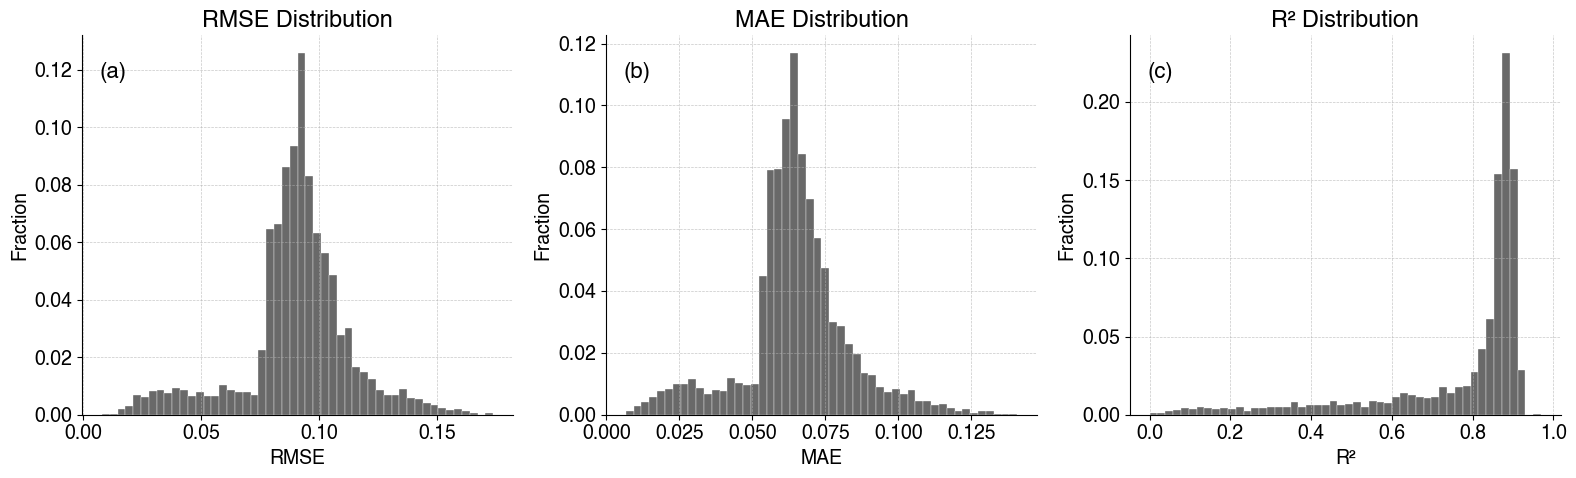

In [16]:
# Set font to Helvetica globally
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['font.size'] = 14  # Set global font size, adjust as needed

# Create plots showing metric distributions (3 panels horizontally)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bar_kwargs = dict(
    color='dimgray',  # dark gray
    edgecolor='white',  # thin white line around each bar
    linewidth=0.25,     # very thin line
    alpha=1.0,
)

def plot_density(ax, data, bins=50, label=None):
    # Remove NaNs
    data = data[~np.isnan(data)]
    # Compute histogram (counts, bin edges)
    counts, bin_edges = np.histogram(data, bins=bins)
    # Compute bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    # Compute density: fraction per bin width
    bin_widths = np.diff(bin_edges)
    density = counts / (counts.sum())
    # Plot as bar chart
    ax.bar(bin_centers, density, width=bin_widths, **bar_kwargs)
    return counts, bin_edges

# Panel labels
panel_labels = ['(a)', '(b)', '(c)']
label_kwargs = dict(xy=(0.04, 0.93), xycoords='axes fraction', fontsize=16, fontweight='bold', va='top', ha='left')

# Plot RMSE distribution
counts_rmse, bins_rmse = plot_density(axes[0], rmse.flatten(), bins=50)
axes[0].set_title('RMSE Distribution')
axes[0].set_xlabel('RMSE')
axes[0].set_ylabel('Fraction')
axes[0].annotate(panel_labels[0], **label_kwargs)

# Calculate and print percentage of RMSE values below 0.1, 0.075, and 0.05
rmse_flat = rmse.flatten()
rmse_flat = rmse_flat[~np.isnan(rmse_flat)]
total_rmse = len(rmse_flat)
thresholds_rmse = [0.1, 0.075, 0.05]
for thresh in thresholds_rmse:
    num_below = np.sum(rmse_flat < thresh)
    percent_below = 100.0 * num_below / total_rmse if total_rmse > 0 else np.nan
    print(f"Percentage of RMSE values below {thresh}: {percent_below:.2f}% ({num_below} out of {total_rmse})")

# Plot MAE distribution
counts_mae, bins_mae = plot_density(axes[1], mae.flatten(), bins=50)
axes[1].set_title('MAE Distribution')
axes[1].set_xlabel('MAE')
axes[1].set_ylabel('Fraction')
axes[1].annotate(panel_labels[1], **label_kwargs)

# Calculate and print percentage of MAE values below 0.1, 0.075, and 0.05
mae_flat = mae.flatten()
mae_flat = mae_flat[~np.isnan(mae_flat)]
total_mae = len(mae_flat)
thresholds_mae = [0.1, 0.075, 0.05]
for thresh in thresholds_mae:
    num_below = np.sum(mae_flat < thresh)
    percent_below = 100.0 * num_below / total_mae if total_mae > 0 else np.nan
    print(f"Percentage of MAE values below {thresh}: {percent_below:.2f}% ({num_below} out of {total_mae})")

# Plot R² distribution
counts_r2, bins_r2 = plot_density(axes[2], r2.flatten(), bins=50)
axes[2].set_title('R² Distribution')
axes[2].set_xlabel('R²')
axes[2].set_ylabel('Fraction')
axes[2].annotate(panel_labels[2], **label_kwargs)

# Calculate and print percentage of R² values above 0.8 and 0.9
r2_flat = r2.flatten()
r2_flat = r2_flat[~np.isnan(r2_flat)]
num_above_08 = np.sum(r2_flat > 0.8)
num_above_09 = np.sum(r2_flat > 0.9)
total_r2 = len(r2_flat)
percent_above_08 = 100.0 * num_above_08 / total_r2 if total_r2 > 0 else np.nan
percent_above_09 = 100.0 * num_above_09 / total_r2 if total_r2 > 0 else np.nan
print(f"Percentage of R² values above 0.8: {percent_above_08:.2f}% ({num_above_08} out of {total_r2})")
print(f"Percentage of R² values above 0.9: {percent_above_09:.2f}% ({num_above_09} out of {total_r2})")

# Remove top and right spines, keep only bottom and left axes, add grid
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')
    ax.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

# fig.savefig('./figures/Oct29/figA3-fit-stats.png', dpi=300, bbox_inches='tight')

In [17]:
# Compute the sum over the first and second dimensions (axes 0 and 1) for RMSE, MAE, and R2, ignoring NaNs
rmse_sum = np.nansum(rmse, axis=(0, 1)).reshape(32, 288)
mae_sum = np.nansum(mae, axis=(0, 1)).reshape(32, 288)
r2_sum = np.nansum(r2, axis=(0, 1)).reshape(32, 288)

lat = icefrac_baseline.lat.values
lon = icefrac_baseline.lon.values
lon_grid, lat_grid = np.meshgrid(lon,lat)
lat_grid, lon_grid = lat_grid[-32:, :], lon_grid[-32:, :]

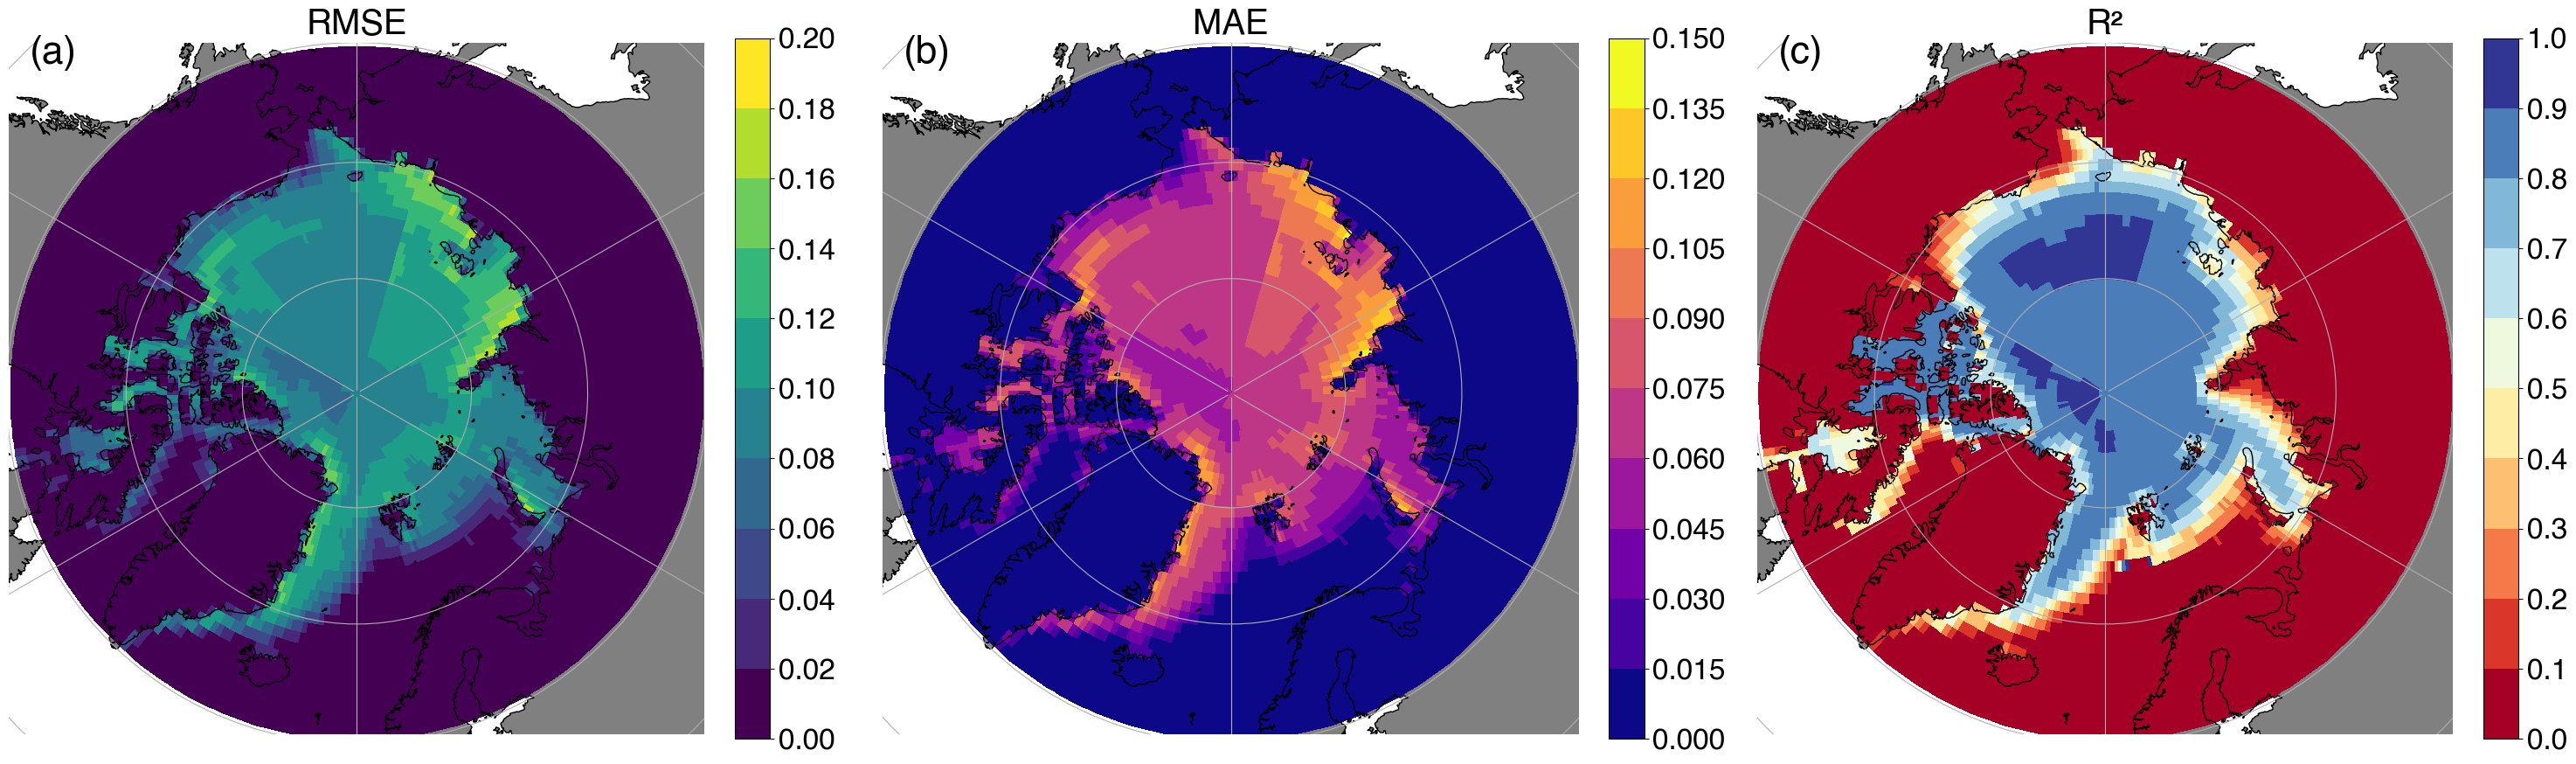

In [18]:
import matplotlib.pyplot as plt
from matplotlib import colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Set up colormaps and bounds for each metric
cmap_rmse = plt.cm.viridis
cmap_mae = plt.cm.plasma
cmap_r2 = plt.cm.RdYlBu

# Set global font family to Helvetica and font size to 16
plt.rcParams.update({'font.family': 'Helvetica', 'font.size': 24})

# Set fixed max values for RMSE and MAE colorbars
rmse_min = np.nanmin(rmse_sum)
rmse_max = 0.2
bounds_rmse = np.linspace(rmse_min, rmse_max, 11)
norm_rmse = colors.BoundaryNorm(boundaries=bounds_rmse, ncolors=cmap_rmse.N, clip=True)

mae_min = np.nanmin(mae_sum)
mae_max = 0.15
bounds_mae = np.linspace(mae_min, mae_max, 11)
norm_mae = colors.BoundaryNorm(boundaries=bounds_mae, ncolors=cmap_mae.N, clip=True)

bounds_r2 = np.linspace(0, 1, 11)
norm_r2 = colors.BoundaryNorm(boundaries=bounds_r2, ncolors=cmap_r2.N, clip=True)

# Create mesh grid for plotting
# (lat_grid, lon_grid are already shaped (32,288))
fig = plt.figure(figsize=(30, 10))

# RMSE plot
ax1 = plt.subplot(131, projection=ccrs.NorthPolarStereo())
ax1.coastlines()
ax1.gridlines()
ax1.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, facecolor='gray')
mesh1 = ax1.pcolormesh(lon_grid, lat_grid, rmse_sum, 
                       transform=ccrs.PlateCarree(),
                       cmap=cmap_rmse, norm=norm_rmse)
cbar1 = plt.colorbar(mesh1, ax=ax1, #label='RMSE',
                     ticks=bounds_rmse, boundaries=bounds_rmse,
                     spacing='proportional', fraction=0.046, pad=0.04)
cbar1.ax.tick_params()#labelsize=14)
# cbar1.set_label('RMSE')#, fontsize=14)
ax1.set_title('RMSE')#, fontsize=16)
# Add panel label
ax1.text(0.03, .96, '(a)', transform=ax1.transAxes, fontsize=32, fontweight='bold', va='bottom', ha='left')
# Remove all borders/spines
for spine in ax1.spines.values():
    spine.set_visible(False)

# MAE plot
ax2 = plt.subplot(132, projection=ccrs.NorthPolarStereo())
ax2.coastlines()
ax2.gridlines()
ax2.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND, facecolor='gray')
mesh2 = ax2.pcolormesh(lon_grid, lat_grid, mae_sum, 
                       transform=ccrs.PlateCarree(),
                       cmap=cmap_mae, norm=norm_mae)
cbar2 = plt.colorbar(mesh2, ax=ax2, #label='MAE',
                     ticks=bounds_mae, boundaries=bounds_mae,
                     spacing='proportional', fraction=0.046, pad=0.04)
cbar2.ax.tick_params()#labelsize=14)
# cbar2.set_label('MAE')#, fontsize=14)
ax2.set_title('MAE')#, fontsize=16)
# Add panel label
ax2.text(0.03, .96, '(b)', transform=ax2.transAxes, fontsize=32, fontweight='bold', va='bottom', ha='left')
for spine in ax2.spines.values():
    spine.set_visible(False)

# R2 plot
ax3 = plt.subplot(133, projection=ccrs.NorthPolarStereo())
ax3.coastlines()
ax3.gridlines()
ax3.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
ax3.add_feature(cfeature.LAND, facecolor='gray')
mesh3 = ax3.pcolormesh(lon_grid, lat_grid, r2_sum, 
                       transform=ccrs.PlateCarree(),
                       cmap=cmap_r2, norm=norm_r2)
cbar3 = plt.colorbar(mesh3, ax=ax3, #label='R²',
                     ticks=bounds_r2, boundaries=bounds_r2,
                     spacing='proportional', fraction=0.046, pad=0.04)
cbar3.ax.tick_params()#labelsize=14)
# cbar3.set_label('R²')#, fontsize=14)
ax3.set_title('R²')#, fontsize=16)
# Add panel label
ax3.text(0.03, .96, '(c)', transform=ax3.transAxes, fontsize=32, fontweight='bold', va='bottom', ha='left')
for spine in ax3.spines.values():
    spine.set_visible(False)

# plt.suptitle('Arctic RMSE, MAE, and R²', fontsize=20)
plt.tight_layout()
plt.show()
# fig.savefig('./figures/Oct29/figA4-fit-stats-maps.png', dpi=300, bbox_inches='tight')

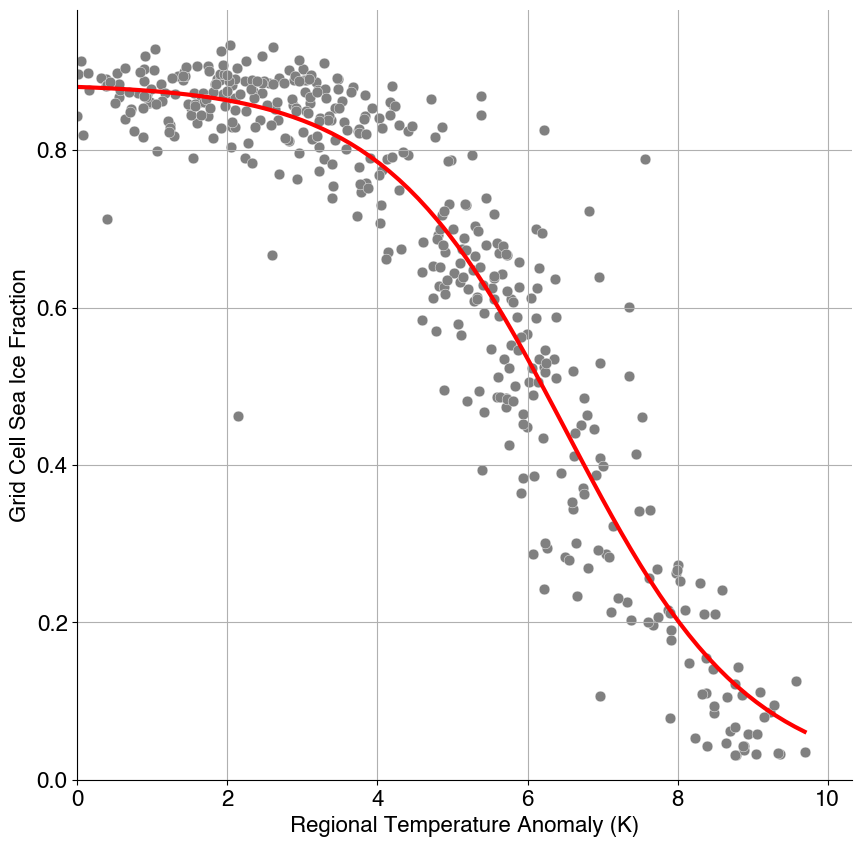

In [19]:
lat_bin = 5
lon_bin = 3
ix, iy = 1, 9189
# Get data for index 0,136
x_clean = X[lon_bin, lat_bin]
y_clean = Y[lon_bin, lat_bin, :, iy]

# Get fitted parameters and generate prediction
popt = params[:, lon_bin, lat_bin, iy]
x_smooth = np.linspace(np.nanmin(x_clean), np.nanmax(x_clean), 100)
y_pred = logistic(x_smooth, *popt)

# Create plot with Helvetica font and font size 12, remove top/right spines, no legend
plt.figure(figsize=(10,10))
plt.rcParams.update({'font.family': 'Helvetica', 'font.size': 16})
plt.scatter(x_clean, y_clean, color='gray', edgecolor='white', linewidth=0.3, s=60)
plt.plot(x_smooth, y_pred, 'r-', linewidth=3)
plt.xlabel('Regional Temperature Anomaly (K)')
plt.ylabel('Grid Cell Sea Ice Fraction')
# plt.title(f'Logistic Fit at Index ({ix},{iy})\nR² = {r2[ix,iy]:.4f}')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.grid(True)
plt.show()


## Validate the fit

In [20]:
icefrac_sai = read_file('../../../sai-simulator-internal/data/processed/icefrac/output_gauss-1.0.nc')
cesm_Y = reshape_icefrac_data(icefrac_sai, start_year='2050', end_year='2069')
cesm_Y.shape

(4, 6, 20, 9216)

In [21]:
from scipy.io import loadmat
emulated_tas = loadmat('../data/CIDER_patterns_for_Ali_2.mat')

emulated_tas = emulated_tas['CIDER_patterns_for_Ali'].mean(axis=-1)[:,:,-20:]

lat = tas_baseline.lat.values
lon = tas_baseline.lon.values
years = np.arange(2050, 2070)  # 20 years

# avg_temp_validation is assumed to be (lat, lon, time) or (nlon, nlat, ntime)
# We want to ensure the order is (time, lat, lon)
# If input is (nlon, nlat, ntime)
if emulated_tas.shape[0] == len(lon) and emulated_tas.shape[1] == len(lat):
    # (nlon, nlat, ntime) --> (ntime, nlat, nlon)
    data_time_lat_lon = np.transpose(emulated_tas, (2,1,0))
elif emulated_tas.shape[-1] == len(years) and emulated_tas.shape[0] == len(lat) and emulated_tas.shape[1] == len(lon):
    # Already (lat, lon, time) --> (time, lat, lon)
    data_time_lat_lon = np.transpose(emulated_tas, (2,0,1))
else:
    # Fallback: try (lat, lon, time) assumed
    data_time_lat_lon = np.transpose(emulated_tas, (2,0,1))

# Create a Dataset and add tas as a variable, now (time, lat, lon)
temp_xr = xr.Dataset(
    {
        "tas": (["time", "lat", "lon"], data_time_lat_lon)
    },
    coords={
        "lat": lat,
        "lon": lon,
        "time": years
    }
)

emulated_tas_ = np.squeeze(
    np.array(
        calculate_temperature_anomalies(
            create_arctic_dataset(temp_xr),
            tas_arctic_baseline,
            start_year=years[0], end_year=years[-1])
    )
)


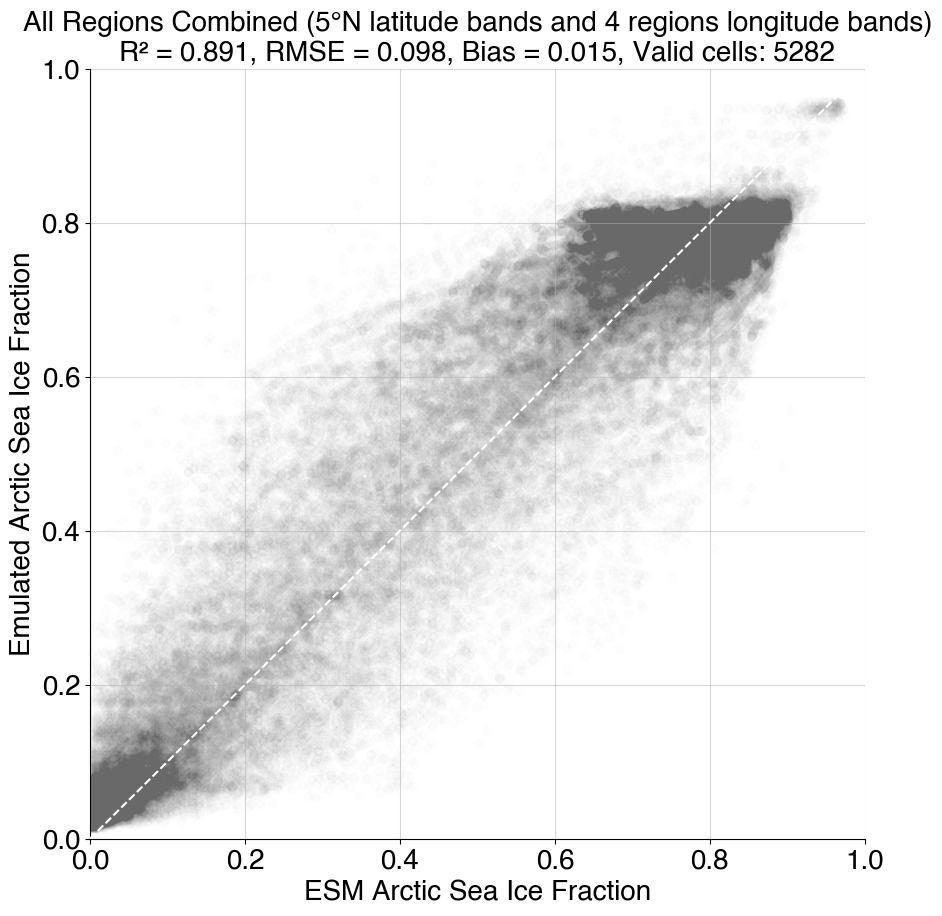

In [22]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

number_of_lat_bands = 6
number_of_lon_bands = 4

# Aggregate all predictions and actuals across all lat-lon bands
all_predictions_total = []
all_actuals_total = []
total_valid_cells = 0

# Loop through all lat-lon bands
for lat in range(number_of_lat_bands):
    for lon in range(number_of_lon_bands):
        # For each grid point
        for j in range(9216):
            popt = params[:, lon, lat, j]  # Get parameters for this lat-lon band and grid point
            # y_pred = logistic(uncoord_X_sai_[lon, lat, :], *popt)  # Predict using the temperature points
            y_pred = logistic(emulated_tas_[lon, lat, :], *popt)  # Predict using the temperature points
            y_true = cesm_Y[lon, lat, :, j]  # Get actual values for this grid point
            
            # Only include non-NaN values
            mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
            if np.any(mask):
                all_predictions_total.extend(y_pred[mask])
                all_actuals_total.extend(y_true[mask])
                total_valid_cells += 1

# Convert to numpy arrays
all_predictions_total = np.array(all_predictions_total)
all_actuals_total = np.array(all_actuals_total)

# Set the font to Helvetica and font size to 16
plt.rcParams['font.family'] = 'Helvetica'
fontsizes = 20
plt.rcParams['font.size'] = fontsizes

# Create single scatter plot
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(
    all_actuals_total, all_predictions_total, 
    alpha=0.01, 
    label='Data points', 
    color='dimgray',
    # linewidths=0.1,
    # edgecolors=(1,1,1,0.1)
)
ax.plot([0, 1], [0, 1], '--', color='white', label='1:1 line', zorder=10)

# Calculate and display metrics
r2 = r2_score(all_actuals_total, all_predictions_total)
rmse = np.sqrt(mean_squared_error(all_actuals_total, all_predictions_total))
bias = np.mean(all_predictions_total - all_actuals_total)
metrics_text = f'R² = {r2:.3f}, RMSE = {rmse:.3f}, Bias = {bias:.3f}, Valid cells: {total_valid_cells}'

ax.set_xlabel('ESM Arctic Sea Ice Fraction', fontsize=fontsizes)
ax.set_ylabel('Emulated Arctic Sea Ice Fraction', fontsize=fontsizes)
ax.set_title(f'All Regions Combined (5°N latitude bands and 4 regions longitude bands)\n{metrics_text}', fontsize=fontsizes)
ax.grid(True, alpha=0.5)
ax.tick_params(axis='both', which='major', labelsize=fontsizes)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Remove right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# plt.legend()  # Uncomment if you want the legend
plt.show()


In [23]:
number_of_lat_bands= 6
number_of_lon_bands= 4

# First create predict_Y with same dimensions as uncoord_Y
predict_Y = np.zeros_like(cesm_Y)  # Initialize with same shape as uncoord_Y
for lat in range(number_of_lat_bands):
    for lon in range(number_of_lon_bands):
        for j in range(predict_Y.shape[-1]):
            popt = params[:, lon, lat, j]  # Get parameters for this lat-lon band and grid point
            # predict_Y[lon, lat, :, j] = logistic(uncoord_X_sai_[lon, lat, :], *popt)  # Predict using the temperature points
            predict_Y[lon, lat, :, j] = logistic(emulated_tas_[lon, lat, :], *popt)  # Predict using the temperature points

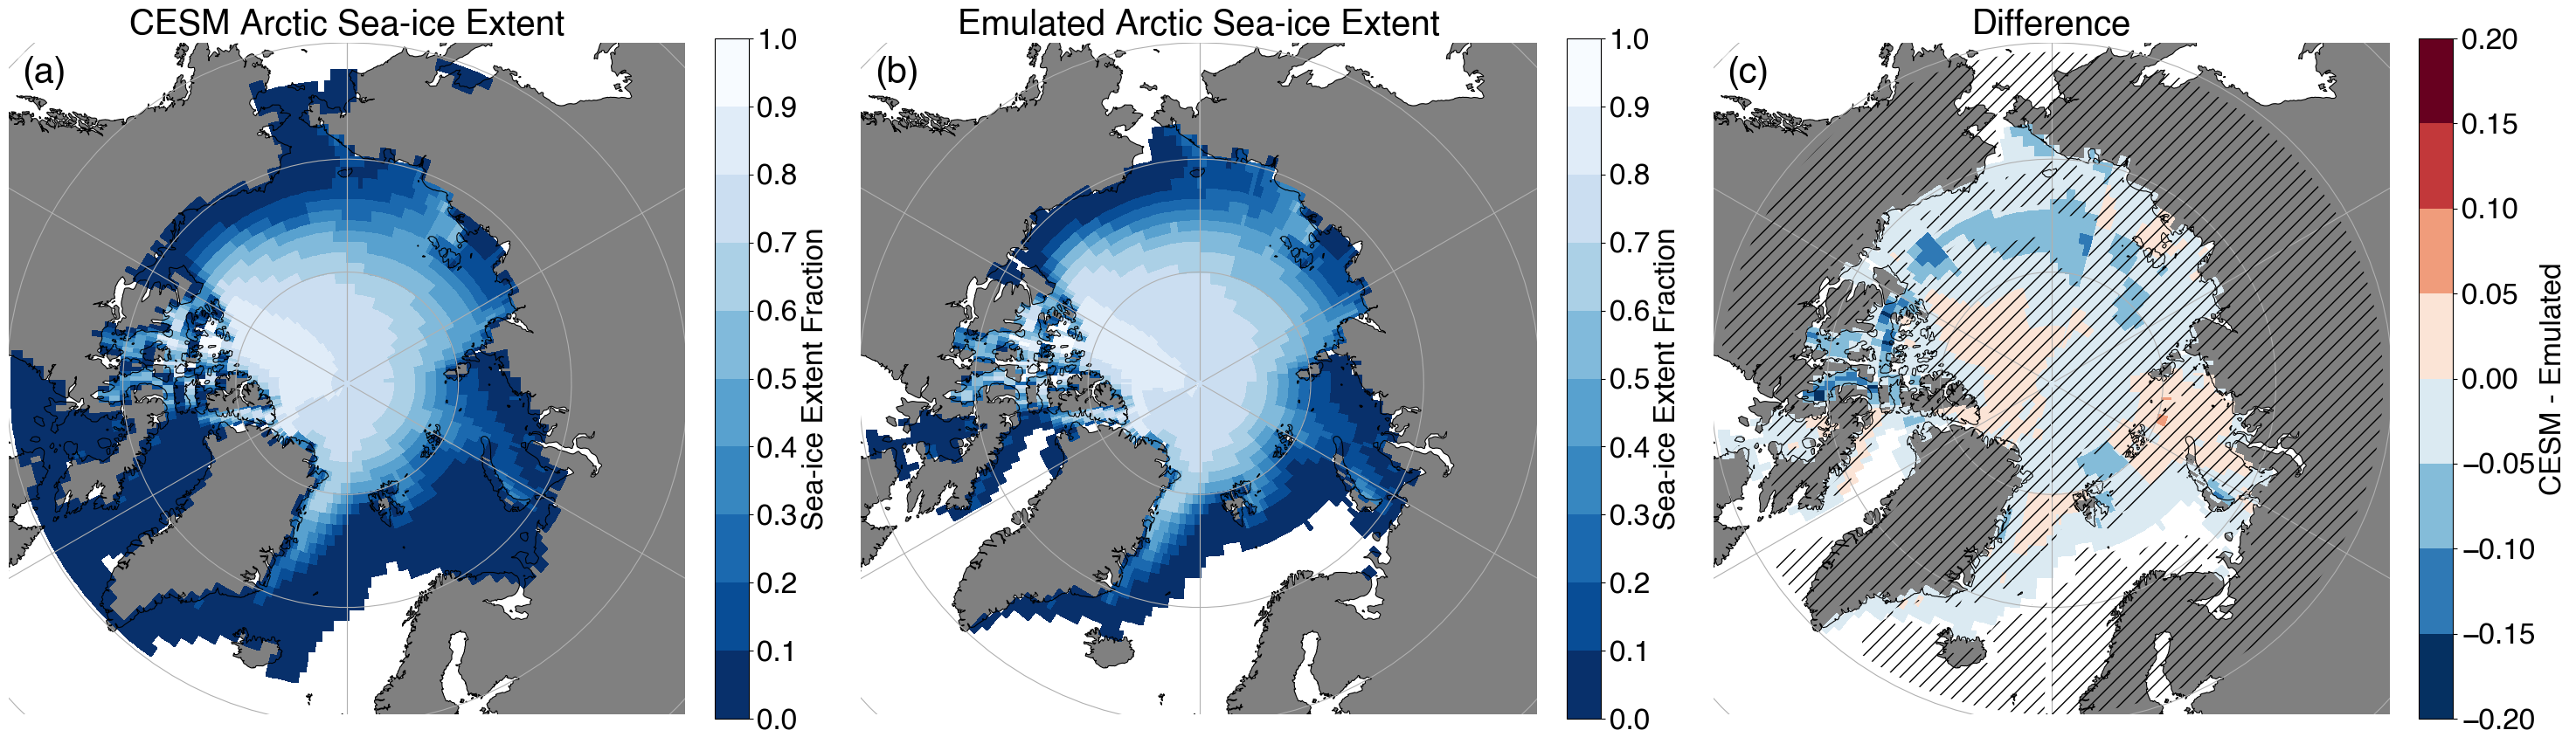

In [24]:
from matplotlib import colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature 
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['font.size'] = 24

from scipy.stats import ttest_rel
import numpy as np

def calculate_Y_mean(Y):
    Y = Y.reshape(*Y.shape[:-1], 32, 288)
    Y = np.nansum(Y, axis=(0, 1))
    Y_mean = np.nanmean(Y, axis=0)
    Y_mean = np.where(Y_mean == 0, np.nan, Y_mean)
    return Y_mean

def reshape_y_for_ttest(Y):
    Y = Y.reshape(*Y.shape[:-1], 32, 288)
    return np.nansum(Y, axis=(0, 1))  # (time, 32, 288)

actual_Y_mean = calculate_Y_mean(cesm_Y)
predict_Y_mean = calculate_Y_mean(predict_Y)
diff_Y = actual_Y_mean - predict_Y_mean

# Calculate p-values: (time, 32, 288) arrays
cesm_Y_ = reshape_y_for_ttest(cesm_Y)
emulated_Y = reshape_y_for_ttest(predict_Y)
t_statistic, p_value = ttest_rel(cesm_Y_, emulated_Y, axis=0, nan_policy='omit')

# Mask p_value where all predicted are nan
all_nan_pred = np.all(np.isnan(emulated_Y), axis=0)   # shape (32,288)
p_value_masked = np.where(all_nan_pred, np.nan, p_value)
mask_significant = (p_value_masked < 0.05)  # True where significant

# Get lat/lon values for Arctic region
lats = tas_baseline.sel(lat=slice(60, 90)).lat.values
lons = tas_baseline.sel(lon=slice(0, 360)).lon.values

# Create mesh grid for plotting
lon_mesh, lat_mesh = np.meshgrid(lons, lats)
fig = plt.figure(figsize=(30, 10))

# --- Blues colormap (leave nan as default) ---
cmap_blues = plt.cm.Blues_r
bounds_blues = np.linspace(0, 1, 11)
norm_blues = colors.BoundaryNorm(boundaries=bounds_blues, ncolors=cmap_blues.N, clip=True)

# --- Seismic colormap for diff ---
cmap_rdbu = plt.cm.RdBu_r  # diverging colormap for difference plot
bounds_rdbu = np.arange(-0.2, 0.2 + 0.05, 0.05)
norm_rdbu = colors.BoundaryNorm(boundaries=bounds_rdbu, ncolors=cmap_rdbu.N, clip=True)

# Plot CESM output values
ax1 = plt.subplot(131, projection=ccrs.NorthPolarStereo())
ax1.coastlines(linewidth=0.8)
ax1.gridlines(linewidth=0.8)
ax1.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, facecolor='gray', edgecolor='none')
mesh1 = ax1.pcolormesh(
    lon_mesh, lat_mesh, actual_Y_mean.reshape(32, 288),
    transform=ccrs.PlateCarree(),
    cmap=cmap_blues,
    norm=norm_blues,
    shading='auto'
)
cbar1 = plt.colorbar(
    mesh1, ax=ax1, label='Sea-ice Extent Fraction',
    ticks=bounds_blues, boundaries=bounds_blues, 
    spacing='proportional',
    fraction=0.046, pad=0.04
)
cbar1.ax.tick_params()
cbar1.set_label('Sea-ice Extent Fraction')
ax1.set_title('CESM Arctic Sea-ice Extent')
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.text(
    0.02, 0.98, '(a)',
    transform=ax1.transAxes,
    fontsize=30,
    fontweight='bold',
    va='top', ha='left',
    bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.5)
)

# Plot emulated values
ax2 = plt.subplot(132, projection=ccrs.NorthPolarStereo())
ax2.coastlines(linewidth=0.8)
ax2.gridlines(linewidth=0.8)
ax2.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND, facecolor='gray', edgecolor='none')
mesh2 = ax2.pcolormesh(
    lon_mesh, lat_mesh, predict_Y_mean.reshape(32, 288),
    transform=ccrs.PlateCarree(),
    cmap=cmap_blues,
    norm=norm_blues,
    shading='auto'
)
cbar2 = plt.colorbar(mesh2, ax=ax2, label='Sea-ice Extent Fraction',
                     ticks=bounds_blues, boundaries=bounds_blues,
                     spacing='proportional', 
                     fraction=0.046, pad=0.04)
cbar2.ax.tick_params()
cbar2.set_label('Sea-ice Extent Fraction')
ax2.set_title('Emulated Arctic Sea-ice Extent')
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.text(
    0.02, 0.98, '(b)',
    transform=ax2.transAxes,
    fontsize=30,
    fontweight='bold',
    va='top', ha='left',
    bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.5)
)

# Plot difference values with hatching where p-value is significant
ax3 = plt.subplot(133, projection=ccrs.NorthPolarStereo())
ax3.coastlines(linewidth=0.8)
ax3.gridlines(linewidth=0.8)
ax3.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
ax3.add_feature(cfeature.LAND, facecolor='gray', edgecolor='none')
mesh3 = ax3.pcolormesh(
    lon_mesh, lat_mesh, diff_Y.reshape(32, 288),
    transform=ccrs.PlateCarree(),
    cmap=cmap_rdbu,
    norm=norm_rdbu,
    shading='auto'
)

# --- Make sure hatching shows up! ---
# Instead of using a transparent or 'none' "facecolor", plot an actual white/transparent colormap,
# but crucially, we use a regular colormap (with alpha=0) for the cell fill, and use a "hatch"
# with a visible edgecolor; further, we plot hatch on top and plot for all grid boxes, but mask it
# by only hatching significant p-value cells. Matplotlib occasionally ignores hatching for fully
# transparent/facecolor='none', so to ensure this, use a nearly-transparent color instead.

# Build a numeric mask for contourf: 1 where significant, NaN elsewhere
sig = np.where(mask_significant, np.nan, 1)

# Choose levels so that the top bin (>=0.5..1) gets hatched
levels = [0.0, 0.5, 1.0]

# Overlay hatching only (no facecolor) on significant cells
# Note: colors='none' is the key so only the hatch is drawn.
# zorder above mesh3 so the hatch sits on top.
if np.isfinite(sig).any():
    ax3.contourf(
        lon_mesh, lat_mesh, sig,
        levels=levels,
        hatches=['', '//'],   # no hatch for [0..0.5), hatch for [0.5..1]
        colors='none',          # don't paint faces, just hatch
        transform=ccrs.PlateCarree(),
        zorder=6
    )

# Set the edgecolor for hatching to a higher visibility if needed (sometimes black is best).
# Remove the line below if not needed for your backend
# for pc in pmesh_hatch.get_paths():
#     pc._hatch_color = (0,0,0,1) # force mattplotlib to use black hatch (for some backends)

cbar3 = plt.colorbar(mesh3, ax=ax3, label='CESM - Emulated Difference',
                     ticks=bounds_rdbu, boundaries=bounds_rdbu,
                     spacing='proportional',
                     fraction=0.046, pad=0.04)
cbar3.ax.tick_params()
cbar3.set_label('CESM - Emulated')
ax3.set_title('Difference')
for spine in ax3.spines.values():
    spine.set_visible(False)
ax3.text(
    0.02, 0.98, '(c)',
    transform=ax3.transAxes,
    fontsize=30,
    fontweight='bold',
    va='top', ha='left',
    bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.5)
)

plt.tight_layout()

# plt.savefig('./figures/Oct29/fig8-cesm-emulated-diff.png', dpi=300, bbox_inches='tight')

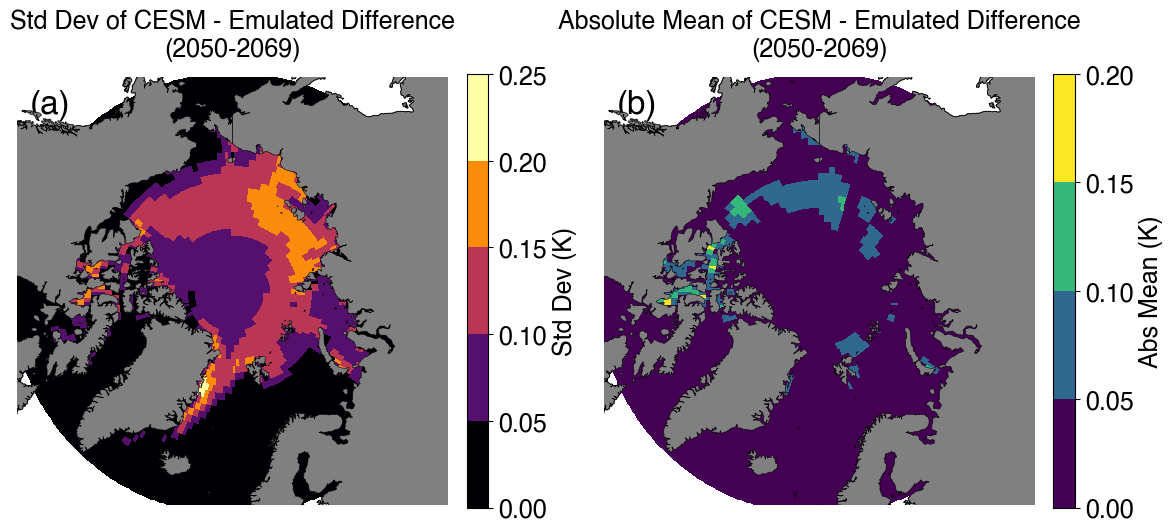

In [25]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib as mpl
import matplotlib.colors as colors

# Colormaps and colorbar boundaries as in @file_context_0
cmap_inferno = plt.cm.inferno
cmap_viridis = plt.cm.viridis
cmap_rdbu = plt.cm.RdBu_r  # unused here but available for later

# Font settings: uniformly use size 14 everywhere we specify font
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['font.size'] = 18

# Compute difference between model and emulator across time, for each lat/lon
diff = cesm_Y_ - emulated_Y    # (20, 32, 288)

# Metrics for each gridcell over time
mean_diff = np.nanmean(diff, axis=0)               # (32, 288)
std_diff = np.nanstd(diff, axis=0)                 # (32, 288)
abs_mean_diff = np.abs(mean_diff)                  # (32, 288)

# Prepare lat/lon mesh for plotting
lats = np.linspace(60, 90, 32)
lons = np.linspace(0, 360, 288, endpoint=False)
lon_mesh, lat_mesh = np.meshgrid(lons, lats)

# Set up 2-panel figure (removing 3rd panel)
fig, axs = plt.subplots(
    1, 2, figsize=(12, 7),
    subplot_kw=dict(projection=ccrs.NorthPolarStereo())
)

# Use coarser steps for the colorbar boundaries as requested (make steps bigger)
# Panel a: 0 to 0.24 with step 0.06, Panel b: 0 to 0.2 with step 0.05
bounds_a = np.arange(0, 0.25 + 0.05, 0.05)
bounds_b = np.arange(0, 0.2 + 0.05, 0.05)

panels = [
    # Standard deviation with inferno colormap, max fixed at 0.24, steps of 0.06
    (
        std_diff, cmap_inferno,
        'Std Dev of CESM - Emulated Difference\n(2050-2069)', 'Std Dev (K)',
        bounds_a,
        colors.BoundaryNorm(boundaries=bounds_a, ncolors=cmap_inferno.N, clip=True),
        'a'
    ),
    # Absolute mean difference with viridis colormap, max fixed at 0.2, steps of 0.05
    (
        abs_mean_diff, cmap_viridis,
        'Absolute Mean of CESM - Emulated Difference\n(2050-2069)', 'Abs Mean (K)',
        bounds_b,
        colors.BoundaryNorm(boundaries=bounds_b, ncolors=cmap_viridis.N, clip=True),
        'b'
    )
]

for ax, (data, cmap, panel_title, cbar_label, cbar_bounds, cbar_norm, tag) in zip(axs, panels):
    mesh = ax.pcolormesh(
        lon_mesh, lat_mesh, data,
        cmap=cmap,
        norm=cbar_norm,
        shading='auto',
        transform=ccrs.PlateCarree(),
        zorder=2
    )
    ax.coastlines()
    ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
    # Move LAND to be on top in the visual stack, using a higher zorder
    # Now: Give a black thick border (edgecolor='black', linewidth=2)
    ax.add_feature(
        cfeature.LAND, 
        facecolor='gray', 
        edgecolor='black', 
        linewidth=.4, 
        zorder=10
    )
    # Colorbar with fixed ticks and boundary normalization, matching @file_context_0 style
    cbar = plt.colorbar(
        mesh, ax=ax,
        boundaries=cbar_bounds,
        ticks=cbar_bounds,
        spacing='proportional',
        fraction=0.046, pad=0.04
    )
    # Uniform font size 14 for colorbar label and ticks
    cbar.set_label(cbar_label, fontsize=18)
    cbar.ax.tick_params(labelsize=18)
    ax.set_title(panel_title, pad=15, fontsize=18)
    # Set the desired font size for (a) and (b) panel labels
    panel_label_fontsize = 24
    # Panel label (a), (b) with increased font size
    ax.text(
        0.03, 0.97, f"({tag})",
        transform=ax.transAxes,
        fontsize=panel_label_fontsize,
        fontweight='bold',
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.6)
    )
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()
# fig.savefig("./figures/Oct29/figA5-absMean-stdDev.png", dpi=300, bbox_inches='tight')